In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import numpy as np
import os

LAYER_STYLE = {
    'M8': {'color': 'cyan', 'alpha': 0.4, 'z': 8 },  
    'M7': {'color': 'red', 'alpha': 0.5, 'z': 7},   
    'M6': {'color': 'magenta', 'alpha': 0.4, 'z': 6},
    'M5': {'color': 'yellow', 'alpha': 0.3, 'z': 5},
    'M4': {'color': 'blue', 'alpha': 0.3, 'z': 4},
    'M3': {'color': 'green', 'alpha': 0.3, 'z': 3},
    'M2': {'color': 'orange', 'alpha': 0.3, 'z': 2},
    'M1': {'color': 'pink', 'alpha': 0.08, 'z': 1},               
    'VIA': {'color': 'black', 'alpha': 0.8, 'z': 10}              
}


In [6]:
import numpy as np
import os

base = 'e:/IR_drop/data/IR_drop'
items = sorted(os.listdir(base))
results = []
for item in items:
    path = os.path.join(base, item)
    data = np.load(path)
    if data.max() > 30:
        results.append(item)

with open('e:/IR_drop/samples_over40.txt', 'w') as f:
    for r in results:
        f.write(r + '\n')
print('Saved to e:/IR_drop/samples_over40.txt')

Saved to e:/IR_drop/samples_over40.txt


In [4]:
results

['10014-zero-riscy-b-3-c2-u0.9-m1-p3-f1',
 '10016-zero-riscy-b-3-c2-u0.9-m1-p5-f1',
 '10018-zero-riscy-b-3-c2-u0.9-m1-p7-f1',
 '10020-zero-riscy-b-3-c2-u0.9-m2-p3-f1',
 '10026-zero-riscy-b-3-c2-u0.9-m3-p6-f1',
 '10052-zero-riscy-b-3-c5-u0.75-m1-p1-f0',
 '10172-zero-riscy-b-3-c5-u0.75-m1-p1-f1',
 '136-RISCY-a-1-c2-u0.7-m2-p1-f1',
 '138-RISCY-a-1-c2-u0.7-m2-p3-f1',
 '139-RISCY-a-1-c2-u0.7-m2-p4-f1',
 '140-RISCY-a-1-c2-u0.7-m2-p5-f1',
 '146-RISCY-a-1-c2-u0.7-m3-p3-f1',
 '1529-RISCY-a-3-c2-u0.75-m3-p3-f1',
 '1536-RISCY-a-3-c2-u0.8-m1-p2-f1',
 '1537-RISCY-a-3-c2-u0.8-m1-p3-f1',
 '1553-RISCY-a-3-c2-u0.8-m3-p3-f1',
 '1566-RISCY-a-3-c2-u0.85-m1-p8-f1',
 '1567-RISCY-a-3-c2-u0.85-m2-p1-f1',
 '157-RISCY-a-1-c2-u0.75-m1-p6-f1',
 '1576-RISCY-a-3-c2-u0.85-m3-p2-f1',
 '1580-RISCY-a-3-c2-u0.85-m3-p6-f1',
 '1583-RISCY-a-3-c2-u0.9-m1-p1-f1',
 '1596-RISCY-a-3-c2-u0.9-m2-p6-f1',
 '160-RISCY-a-1-c2-u0.75-m2-p1-f1',
 '161-RISCY-a-1-c2-u0.75-m2-p2-f1',
 '163-RISCY-a-1-c2-u0.75-m2-p4-f1',
 '164-RISCY-a-1-c2-u

c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


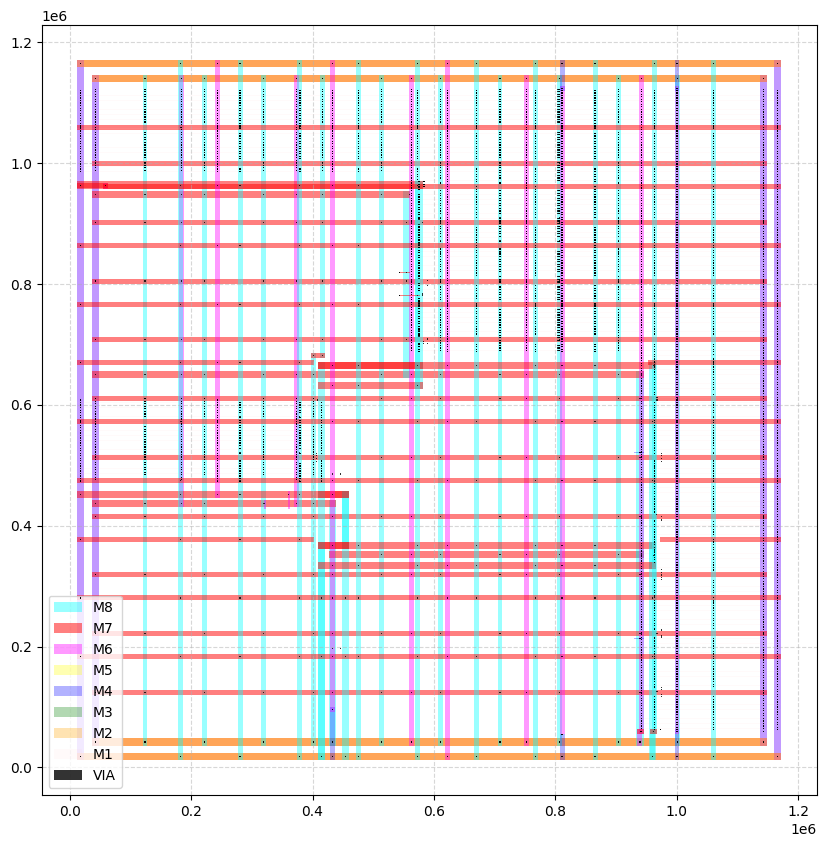

In [3]:
file_name = "E:/IR_drop/826-RISCY-a-2-c2-u0.8-m4-p8-f0.def"
NET_Y_OFFSET = {'VDD': 0, 'VSS': 0}
fig, ax = plt.subplots(figsize=(10, 10))
found_section = False
curr_layer, curr_width = None, 0
last_x, last_y = 0, 0
counts = {'rect': 0, 'via': 0}


with open(file_name, 'r') as f:
    for line in f:
        if line.lstrip().startswith("SPECIALNETS"):
            found_section = True
            continue
        if not found_section:
            continue
        if line.startswith("END SPECIALNETS") or (line.startswith(";") and "NEW" not in line):
            break
        if not ('ROUTED' in line or 'NEW' in line): continue
        if '(' not in line: continue
        meta = re.search(r'(M\d+)\s+(\d+)', line)
        if meta:
                curr_layer = meta.group(1)
                curr_width = int(meta.group(2))
        pts = re.findall(r'\(\s*([\d\*\-]+)\s+([\d\*\-]+)\s*\)', line)
        if not pts: continue
        x1_s, y1_s = pts[0]
        curr_x = last_x if x1_s == '*' else int(x1_s)
        curr_y = last_y if y1_s == '*' else int(y1_s)

        
        if " VIA " in line or curr_width == 0:
            v_style = LAYER_STYLE['VIA']
            v_size = 2000 if curr_width == 0 else curr_width
            ax.add_patch(patches.Rectangle((curr_x - v_size/2, curr_y - v_size/2), 
                                            v_size, v_size, 
                                            facecolor=v_style['color'], 
                                            alpha=v_style['alpha'], zorder=v_style['z'], lw=0))
            counts['via'] += 1
            last_x, last_y = curr_x, curr_y
            if len(pts) < 2 and "NEW" not in line and "ROUTED" not in line:
                    continue
      
            
        if curr_layer in LAYER_STYLE and curr_width > 0:
            style = LAYER_STYLE[curr_layer]
            z = style['z'] 

            for i in range(1, len(pts)):
                x2_s, y2_s = pts[i]
                end_x = curr_x if x2_s == '*' else int(x2_s)
                end_y = curr_y if y2_s == '*' else int(y2_s)
                
   
                if curr_x == end_x: 
                    if abs(curr_y - end_y) < 1: 
                            curr_x, curr_y = end_x, end_y
                            continue 
                    xmin = curr_x - curr_width / 2
                    ymin = min(curr_y, end_y)
                    rect_w, rect_h = curr_width, abs(curr_y - end_y)
                else:
                    xmin = min(curr_x, end_x)
                    ymin = curr_y - curr_width / 2
                    rect_w, rect_h = abs(curr_x - end_x), curr_width
                
           
                rect = patches.Rectangle((xmin, ymin), rect_w, rect_h, 
                                            facecolor=style['color'], 
                                            alpha=style['alpha'],
                                            edgecolor=None, linewidth=0) 
           
                ax.add_patch(rect)
                counts['rect'] += 1
                
         
                curr_x, curr_y = end_x, end_y
            
    
            last_x, last_y = curr_x, curr_y
    



ax.autoscale_view()
plt.grid(True, linestyle='--', alpha=0.5)
legend_elements = [patches.Patch(facecolor=style['color'], alpha=style['alpha'], label=layer)
                       for layer, style in LAYER_STYLE.items()]
ax.legend(handles=legend_elements)
plt.show()


In [ ]:
import re
from collections import defaultdict

def analyze_def_pdn(file_name):
    # 统计字典: stats[layer][shape] = count
    stats = defaultdict(lambda: defaultdict(int))
    # 宽度存储: 查看各层典型的线宽
    layer_widths = defaultdict(set)
    
    found_section = False
    curr_net = None
    curr_layer = None
    
    # 匹配规则
    # 匹配层级和宽度: ROUTED M5 400 或 NEW M1 200
    meta_re = re.compile(r'(?:ROUTED|NEW|FIXED)\s+(?P<layer>M\d+|VIA\d+)\s+(?P<width>\d+)')
    # 匹配形状: SHAPE STRIPE
    shape_re = re.compile(r'SHAPE\s+(?P<shape>\w+)')
    
    with open(file_name, 'r') as f:
        for line in f:
            line = line.strip()
            
            # 进入 SPECIALNETS 区域
            if line.startswith("SPECIALNETS"):
                found_section = True
                continue
            if not found_section:
                continue
            if line.startswith("END SPECIALNETS"):
                break
                
            # 识别当前网络 (VDD/VSS)
            if line.startswith("- "):
                curr_net = line.split()[1]
                continue
                
            # 提取层级和宽度
            meta_match = meta_re.search(line)
            if meta_match:
                curr_layer = meta_match.group('layer')
                width = meta_match.group('width')
                layer_widths[curr_layer].add(width)
                
                # 提取形状
                shape_match = shape_re.search(line)
                shape = shape_match.group('shape') if shape_match else "UNKNOWN"
                
                # 如果包含 VIA 关键字，标记为 VIA
                if " VIA " in line:
                    stats[curr_layer]["VIA_CONNECTION"] += 1
                else:
                    stats[curr_layer][shape] += 1

    # 打印分析报告
    print(f"{'Layer':<10} | {'Shape':<15} | {'Count':<8} | {'Widths':<15} | {'Role in Modeling'}")
    print("-" * 80)
    
    for layer in sorted(stats.keys()):
        for shape, count in stats[layer].items():
            widths = ", ".join(sorted(list(layer_widths[layer])))
            role = get_modeling_role(layer, shape)
            print(f"{layer:<10} | {shape:<15} | {count:<8} | {widths:<15} | {role}")

def get_modeling_role(layer, shape):
    """根据层和形状定义在 PDN 图模型中的角色"""
    if shape == "FOLLOWPIN":
        return "Lower Rail (M1). 隐式建模，作为 Tile 节点的电阻来源。"
    if shape == "STRIPE":
        return "Main Grid Edge. 图模型的主要边，连接 PDN 骨干节点。"
    if "VIA" in shape or "VIA" in layer:
        return "Vertical Node/Edge. 连接不同金属层的层间阻抗。"
    if "RING" in shape:
        return "Global Boundary. PDN 的外部框架，电压源输入位置。"
    return "Secondary Interconnect."

# 执行分析
file_name = "826-RISCY-a-2-c2-u0.8-m4-p8-f0.def"
analyze_def_pdn(file_name)

Layer      | Shape           | Count    | Widths          | Role in Modeling
--------------------------------------------------------------------------------
M1         | FOLLOWPIN       | 573      | 300             | Lower Rail (M1). 隐式建模，作为 Tile 节点的电阻来源。
M1         | COREWIRE        | 1197     | 300             | Secondary Interconnect.
M2         | FOLLOWPIN       | 2282     | 0, 300          | Lower Rail (M1). 隐式建模，作为 Tile 节点的电阻来源。
M2         | COREWIRE        | 1165     | 0, 300          | Secondary Interconnect.
M3         | FOLLOWPIN       | 2282     | 0               | Lower Rail (M1). 隐式建模，作为 Tile 节点的电阻来源。
M3         | COREWIRE        | 1097     | 0               | Secondary Interconnect.
M4         | BLOCKWIRE       | 2        | 0, 1260, 8100   | Secondary Interconnect.
M4         | FOLLOWPIN       | 2282     | 0, 1260, 8100   | Lower Rail (M1). 隐式建模，作为 Tile 节点的电阻来源。
M4         | COREWIRE        | 1097     | 0, 1260, 8100   | Secondary Interconnect.
M4         | STRIPE       

In [1]:
import numpy as np
import os
import random

base_feature = 'e:/IR_drop/data/IR_drop' 
predata_dir = 'e:/IR_drop' 

hard_samples = []  # > 30
easy_samples = []  # <= 30
items = sorted(os.listdir(base_feature))

print("正在分类样本...")
for item in items:
    path = os.path.join(base_feature, item)
    data = np.load(path)
    
    clean_name = item if item.endswith('.npy') else f"{item}.npy"
    
    if data.max() > 30:
        hard_samples.append(clean_name)
    else:
        easy_samples.append(clean_name)

# --- 新增：随机抽取 500 份不超标样本 ---
num_easy_to_take = min(500, len(easy_samples)) # 防止总数不足 500
selected_easy = random.sample(easy_samples, num_easy_to_take)
print(f"💡 已抽取不超标样本: {len(selected_easy)} 份")

# 合并所有选中的样本
all_selected_samples = hard_samples + selected_easy

# --- 随机打乱并按 8:2 比例切分 ---
random.seed(42) 
random.shuffle(all_selected_samples)

split_index = int(len(all_selected_samples) * 0.8)
train_list = all_selected_samples[:split_index]
val_list = all_selected_samples[split_index:]

# --- 保存函数 ---
def save_to_csv(file_name, data_list):
    path = os.path.join(predata_dir, file_name)
    with open(path, 'w') as f:
        for name in data_list:
            f.write(f"feature/{name},label/{name}\n")
    return path

train_csv = save_to_csv('train.csv', train_list)
val_csv = save_to_csv('val.csv', val_list)

print(f"---")
print(f"✅ 处理完成！")
print(f"📊 总样本数: {len(all_selected_samples)} (超标: {len(hard_samples)}, 正常: {len(selected_easy)})")
print(f"📝 训练集: {train_csv} ({len(train_list)} 份)")
print(f"📝 验证集: {val_csv} ({len(val_list)} 份)")

正在分类样本...
💡 已抽取不超标样本: 500 份
---
✅ 处理完成！
📊 总样本数: 991 (超标: 491, 正常: 500)
📝 训练集: e:/IR_drop\train.csv (792 份)
📝 验证集: e:/IR_drop\val.csv (199 份)


(np.int64(242), np.int64(99))


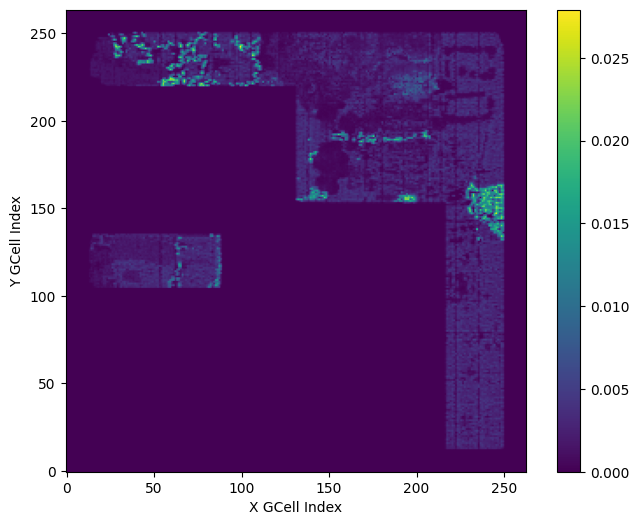

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

all_max = []
all_values_sample = []
file_stats = []
data = np.load('E:/IR_drop/data/power_i/power_i/826-RISCY-a-2-c2-u0.8-m4-p8-f0')
data = data.T
max_val = np.max(data)
max_idx = np.unravel_index(np.argmax(data),data.shape)
print(max_idx)
plt.figure(figsize=(8,6))
plt.imshow(data,cmap='viridis',origin='lower')
plt.xlabel("X GCell Index")
plt.ylabel("Y GCell Index")
plt.colorbar()
plt.show()

In [8]:
import numpy as np

pt = np.load('e:/IR_drop/data/power_t/826-RISCY-a-2-c2-u0.8-m4-p8-f0')
print('shape:', pt.shape)
print()
print('t  | mean        | std         | max         | nonzero%')
print('---+-------------+-------------+-------------+---------')
for t in range(20):
    f = pt[t]
    nz = (f>0).mean()*100
    print(f'{t:2d} | {f.mean():.4e} | {f.std():.4e} | {f.max():.4e} | {nz:.1f}%')

print()
print('相邻帧相关系数:')
for t in range(19):
    corr = np.corrcoef(pt[t].ravel(), pt[t+1].ravel())[0,1]
    print(f'  t{t} vs t{t+1}: {corr:.4f}')

shape: (20, 263, 264)

t  | mean        | std         | max         | nonzero%
---+-------------+-------------+-------------+---------
 0 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00 | 0.0%
 1 | 6.9007e-06 | 9.3852e-05 | 1.0038e-02 | 2.9%
 2 | 4.2989e-05 | 4.0045e-04 | 1.3889e-02 | 11.5%
 3 | 1.7849e-04 | 6.5178e-04 | 1.4896e-02 | 17.9%
 4 | 4.7325e-04 | 1.4998e-03 | 3.3720e-02 | 24.7%
 5 | 6.6938e-04 | 1.8782e-03 | 4.0330e-02 | 30.9%
 6 | 7.1500e-04 | 1.9134e-03 | 4.0330e-02 | 31.0%
 7 | 7.3319e-04 | 1.9135e-03 | 4.0330e-02 | 32.1%
 8 | 7.2689e-04 | 1.9120e-03 | 4.0330e-02 | 32.1%
 9 | 7.2288e-04 | 1.9087e-03 | 4.0330e-02 | 32.0%
10 | 7.1066e-04 | 1.8995e-03 | 4.0330e-02 | 31.9%
11 | 6.1935e-04 | 1.8233e-03 | 4.0330e-02 | 31.7%
12 | 5.3512e-04 | 1.6984e-03 | 4.0210e-02 | 31.3%
13 | 4.5460e-04 | 1.5032e-03 | 4.0029e-02 | 30.3%
14 | 3.8412e-04 | 1.2560e-03 | 3.2149e-02 | 29.3%
15 | 3.2002e-04 | 1.0286e-03 | 2.1370e-02 | 28.5%
16 | 2.5229e-04 | 8.7513e-04 | 2.0898e-02 | 27.5%
17 | 1.6020e-04 |

c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sample = '826-RISCY-a-2-c2-u0.8-m4-p8-f0'
pt = np.load(f'../data/power_t/{sample}')  # (20, H, W)

T, H, W = pt.shape
print(f'shape: {pt.shape}')

# ── 1. 20帧热图 (4行×5列) ──────────────────────────────────────────────
vmax = pt.max()
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
fig.suptitle(f'power_t — 20 time steps\n{sample}', fontsize=13)
for t, ax in enumerate(axes.ravel()):
    im = ax.imshow(pt[t], vmin=0, vmax=vmax, cmap='hot', origin='lower')
    ax.set_title(f't={t}', fontsize=9)
    ax.axis('off')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='power (W)')
plt.savefig('../data/power_t_heatmaps.png', dpi=120, bbox_inches='tight')
plt.close()
print('saved: power_t_heatmaps.png')

# ── 2. 每帧统计曲线 ───────────────────────────────────────────────────
means = pt.reshape(T, -1).mean(axis=1)
stds  = pt.reshape(T, -1).std(axis=1)
maxs  = pt.reshape(T, -1).max(axis=1)
nz    = (pt.reshape(T, -1) > 0).mean(axis=1) * 100

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'power_t — per-timestep statistics\n{sample}', fontsize=12)
ts = np.arange(T)

axes[0,0].plot(ts, means, 'o-', color='steelblue')
axes[0,0].set_title('Mean power per frame')
axes[0,0].set_xlabel('time step'); axes[0,0].set_ylabel('W')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ts, stds, 'o-', color='tomato')
axes[0,1].set_title('Std dev per frame')
axes[0,1].set_xlabel('time step'); axes[0,1].set_ylabel('W')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(ts, maxs, 'o-', color='darkorange')
axes[1,0].set_title('Max power per frame')
axes[1,0].set_xlabel('time step'); axes[1,0].set_ylabel('W')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ts, nz, 'o-', color='seagreen')
axes[1,1].set_title('Non-zero cell ratio per frame (%)')
axes[1,1].set_xlabel('time step'); axes[1,1].set_ylabel('%')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/power_t_stats.png', dpi=120, bbox_inches='tight')
plt.close()
print('saved: power_t_stats.png')

# ── 3. 相邻帧差值热图 ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
fig.suptitle('power_t — frame diff (t+1 − t)', fontsize=13)
diffs = np.diff(pt, axis=0)  # (19, H, W)
dlim = np.abs(diffs).max()
for idx, ax in enumerate(axes.ravel()):
    if idx < 19:
        im = ax.imshow(diffs[idx], vmin=-dlim, vmax=dlim, cmap='RdBu_r', origin='lower')
        ax.set_title(f't{idx}→t{idx+1}', fontsize=9)
    ax.axis('off')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Δpower (W)')
plt.savefig('../data/power_t_diffs.png', dpi=120, bbox_inches='tight')
plt.close()
print('saved: power_t_diffs.png')

# ── 4. 相邻帧相关系数 ─────────────────────────────────────────────────
corrs = [np.corrcoef(pt[t].ravel(), pt[t+1].ravel())[0,1] for t in range(T-1)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(T-1), corrs, color='mediumpurple', alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_title('Pearson correlation between adjacent frames')
ax.set_xlabel('t → t+1'); ax.set_ylabel('correlation')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../data/power_t_corr.png', dpi=120, bbox_inches='tight')
plt.close()
print('saved: power_t_corr.png')

# ── 5. 分布直方图（叠加20帧）────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.plasma(np.linspace(0, 1, T))
for t in range(T):
    vals = pt[t][pt[t] > 0].ravel()
    if len(vals):
        ax.hist(vals, bins=60, alpha=0.4, color=colors[t], density=True, label=f't={t}')
ax.set_title('Distribution of non-zero power values (all 20 frames)')
ax.set_xlabel('power (W)'); ax.set_ylabel('density')
ax.legend(fontsize=6, ncol=4, loc='upper right')
plt.tight_layout()
plt.savefig('../data/power_t_hist.png', dpi=120, bbox_inches='tight')
plt.close()
print('saved: power_t_hist.png')

print('\nDone. 所有图片保存到 data/ 目录.')

shape: (20, 263, 264)
saved: power_t_heatmaps.png
saved: power_t_stats.png
saved: power_t_diffs.png
saved: power_t_corr.png


c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


saved: power_t_hist.png

Done. 所有图片保存到 data/ 目录.


共找到 10242 个样本，扫描前 200 个...
找到 7 个含热点的样本


C:\Users\s1155250660\AppData\Local\Temp\ipykernel_21920\1695051384.py:49: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s1155250660\AppData\Local\Temp\ipykernel_21920\1695051384.py:49: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s1155250660\AppData\Local\Temp\ipykernel_21920\1695051384.py:49: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s1155250660\AppData\Local\Temp\ipykernel_21920\1695051384.py:49: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s1155250660\AppData\Local\Temp\ipykernel_21920\1695051384.py:49: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s1155250660\AppData\Local\Temp\ipykernel_21920\169505138

图像已保存: e:/IR_drop/hotspot_shape_check.png


c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\s1155250660\AppData\Local\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\s1155250660\AppData\Local\m

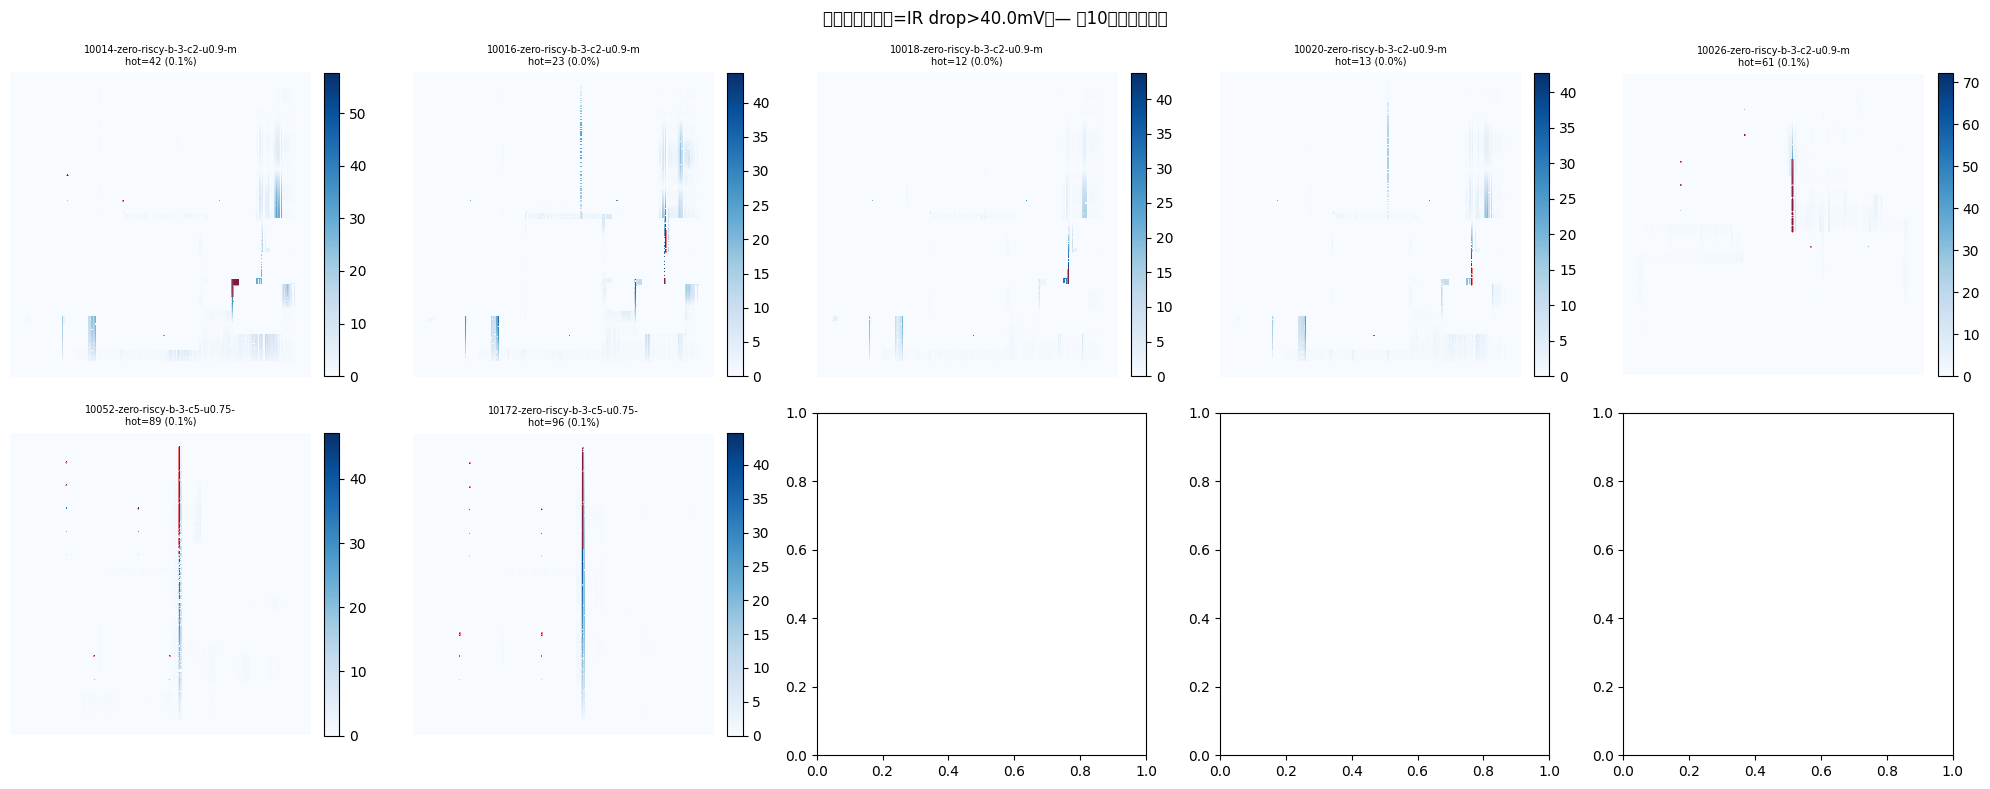

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LABEL_DIR = Path("e:/IR_drop/data/IR_drop")
HOT_THRESH_MV = 40.0
N_SAMPLES = 10

# 找出所有含热点的样本（只扫前 200 个文件，避免太慢）
all_files = sorted(LABEL_DIR.iterdir())
print(f"共找到 {len(all_files)} 个样本，扫描前 200 个...")

hotspot_samples = []
for f in all_files[:200]:
    try:
        ir = np.load(str(f))
        ir_map = ir.max(axis=0) if ir.ndim == 3 else ir  # (H, W)
        if (ir_map > HOT_THRESH_MV).any():
            hotspot_samples.append((f.name, ir_map))
        if len(hotspot_samples) >= N_SAMPLES:
            break
    except Exception as e:
        print(f"  跳过 {f.name}: {e}")

print(f"找到 {len(hotspot_samples)} 个含热点的样本")

# 画图
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (name, ir_map) in enumerate(hotspot_samples):
    ax = axes[i]
    hot_mask = ir_map > HOT_THRESH_MV

    # 背景显示 IR drop 值，热点区域高亮
    im = ax.imshow(ir_map, cmap="Blues", origin="upper", interpolation="nearest")
    # 热点轮廓叠加
    ax.contourf(hot_mask.astype(float), levels=[0.5, 1.5], colors=["red"], alpha=0.5)

    n_hot = hot_mask.sum()
    total = hot_mask.size
    ax.set_title(f"{name[:30]}\nhot={n_hot} ({100*n_hot/total:.1f}%)", fontsize=7)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"热点分布（红色=IR drop>{HOT_THRESH_MV}mV）— 前{N_SAMPLES}个含热点样本",
             fontsize=12)
plt.tight_layout()

out = "e:/IR_drop/hotspot_shape_check.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"图像已保存: {out}")
plt.show()

In [3]:
import numpy as np
import os

folder_path = r"E:\IR_drop\data\IR_drop"

total_all = 0
non_zero_all = 0

for file in os.listdir(folder_path):
    if file:
        file_path = os.path.join(folder_path, file)
        data = np.load(file_path)
        
        total = data.size
        non_zero = np.count_nonzero(data)
        
        total_all += total
        non_zero_all += non_zero
        
        print(f"{file}: {non_zero/total:.6f} ({(non_zero/total)*100:.2f}%)")

# 总体统计
ratio_all = non_zero_all / total_all

print("\n=== 总体统计 ===")
print(f"总元素数: {total_all}")
print(f"非零元素数: {non_zero_all}")
print(f"非零占比: {ratio_all:.6f} ({ratio_all*100:.2f}%)")

1-RISCY-a-1-c2-u0.7-m1-p1-f0: 0.374980 (37.50%)
10-RISCY-a-1-c2-u0.7-m2-p2-f0: 0.377201 (37.72%)
100-RISCY-a-1-c2-u0.85-m2-p3-f0: 0.322435 (32.24%)
1000-RISCY-a-2-c5-u0.75-m2-p1-f0: 0.313027 (31.30%)
10000-zero-riscy-b-3-c2-u0.85-m1-p6-f1: 0.184545 (18.45%)
10001-zero-riscy-b-3-c2-u0.85-m1-p7-f1: 0.186901 (18.69%)
10002-zero-riscy-b-3-c2-u0.85-m1-p8-f1: 0.187392 (18.74%)
10003-zero-riscy-b-3-c2-u0.85-m2-p3-f1: 0.191053 (19.11%)
10004-zero-riscy-b-3-c2-u0.85-m2-p4-f1: 0.186803 (18.68%)
10005-zero-riscy-b-3-c2-u0.85-m2-p5-f1: 0.184040 (18.40%)
10006-zero-riscy-b-3-c2-u0.85-m2-p6-f1: 0.184545 (18.45%)
10007-zero-riscy-b-3-c2-u0.85-m2-p7-f1: 0.186901 (18.69%)
10008-zero-riscy-b-3-c2-u0.85-m2-p8-f1: 0.187350 (18.74%)
10009-zero-riscy-b-3-c2-u0.85-m3-p3-f1: 0.147332 (14.73%)
1001-RISCY-a-2-c5-u0.75-m2-p2-f0: 0.313531 (31.35%)
10010-zero-riscy-b-3-c2-u0.85-m3-p4-f1: 0.149394 (14.94%)
10011-zero-riscy-b-3-c2-u0.85-m3-p6-f1: 0.138593 (13.86%)
10012-zero-riscy-b-3-c2-u0.85-m3-p8-f1: 0.147627 (14

In [6]:
import re
text = open('E:/IR_drop/826-RISCY-a-2-c2-u0.8-m4-p8-f0.def').read()
m = re.search(r'UNITS\s+DISTANCE\s+MICRONS\s+(\d+)', text)
dbu = int(m.group(1)); print('DBU:', dbu)
m2 = re.search(r'DIEAREA\s*\(\s*([\d\-]+)\s+([\d\-]+)\s*\)\s*\(\s*([\d\-]+)\s+([\d\-]+)\s*\)', text)
die = [int(v)/dbu for v in m2.groups()]
print('Die area (um):', die)
print('Width (um):', die[2]-die[0], 'Height (um):', die[3]-die[1])
print('Grid cell width (um):', (die[2]-die[0])/264, 'Grid cell height (um):', (die[3]-die[1])/263)
" 2>&1 || conda run -n myenv python -c "
import re
text = open('E:/IR_drop/826-RISCY-a-2-c2-u0.8-m4-p8-f0.def').read()
m = re.search(r'UNITS\s+DISTANCE\s+MICRONS\s+(\d+)', text)
dbu = int(m.group(1)); print('DBU:', dbu)
m2 = re.search(r'DIEAREA\s*\(\s*([\d\-]+)\s+([\d\-]+)\s*\)\s*\(\s*([\d\-]+)\s+([\d\-]+)\s*\)', text)
die = [int(v)/dbu for v in m2.groups()]
print('Die area (um):', die)
print('Width (um):', die[2]-die[0], 'Height (um):', die[3]-die[1])
print('Grid cell width (um):', (die[2]-die[0])/264, 'Grid cell height (um):', (die[3]-die[1])/263)

DBU: 2000
Die area (um): [0.0, 0.0, 592.2, 591.3]
Width (um): 592.2 Height (um): 591.3
Grid cell width (um): 2.243181818181818 Grid cell height (um): 2.2482889733840303
DBU: 2000
Die area (um): [0.0, 0.0, 592.2, 591.3]
Width (um): 592.2 Height (um): 591.3
Grid cell width (um): 2.243181818181818 Grid cell height (um): 2.2482889733840303


Reading DEF …
  Die: (0.0, 0.0) → (592.2, 591.3) um  [592.2 × 591.3]
  Via definitions parsed: 160
  Segments rasterised: 8272  |  Vias placed: 3339
  M7 cells: 0  M8 cells: 41872  Via cells: 2058
Saved → e:\IR_drop\code\m7_m8_grid.png


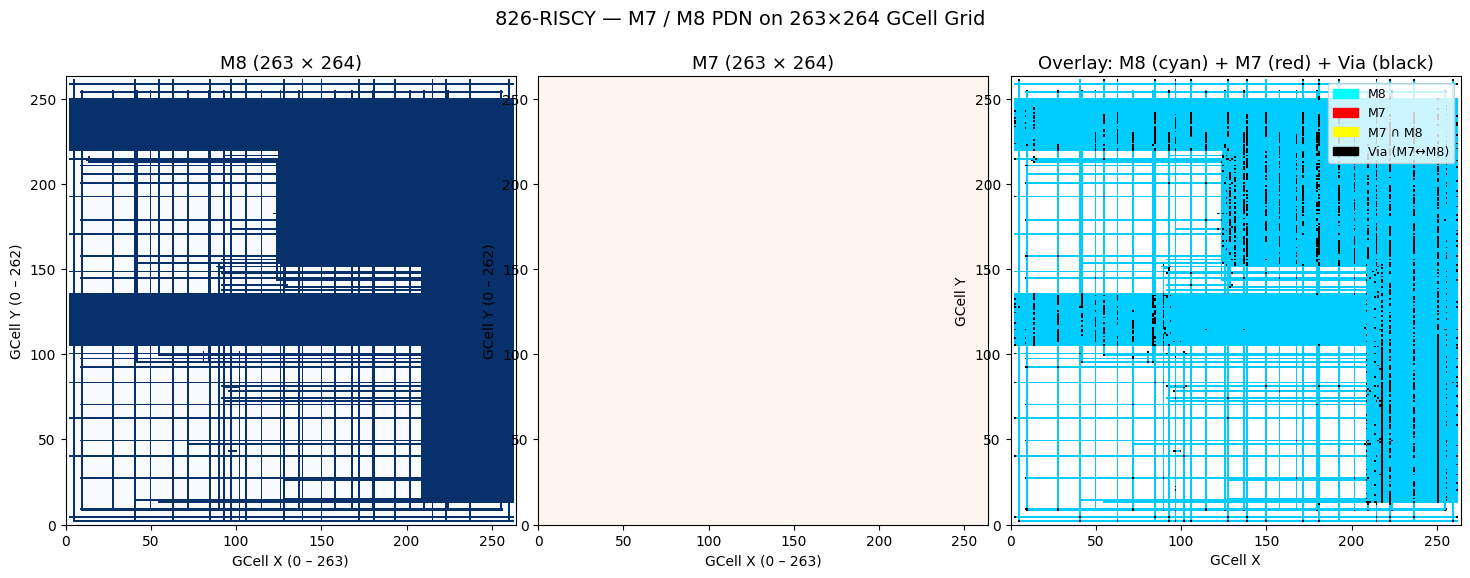

In [7]:
import re
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Config ──────────────────────────────────────────────────────────────────
DEF_PATH = Path("e:/IR_drop/826-RISCY-a-2-c2-u0.8-m4-p8-f0.def")
OUT_PATH  = Path("e:/IR_drop/code/m7_m8_grid.png")
GRID_H, GRID_W = 263, 264          # rows (Y), cols (X)
TARGET_LAYERS = {"M7", "M8"}
VIA_LAYERS    = {"M7", "M8"}       # keep vias touching either layer
DBU = 2000

# ── Parse DEF ───────────────────────────────────────────────────────────────
print("Reading DEF …")
text = DEF_PATH.read_text(encoding="utf-8", errors="ignore")

# die area
m = re.search(r"DIEAREA\s*\(\s*([\d\-]+)\s+([\d\-]+)\s*\)\s*\(\s*([\d\-]+)\s+([\d\-]+)\s*\)", text)
die_x0, die_y0, die_x1, die_y1 = [int(v) / DBU for v in m.groups()]
W_um = die_x1 - die_x0
H_um = die_y1 - die_y0
print(f"  Die: ({die_x0}, {die_y0}) → ({die_x1}, {die_y1}) um  [{W_um:.1f} × {H_um:.1f}]")

def um_to_cell(x_um, y_um):
    """Physical um → (row, col) in the 263×264 grid."""
    col = int((x_um - die_x0) / W_um * GRID_W)
    row = int((y_um - die_y0) / H_um * GRID_H)
    col = max(0, min(GRID_W - 1, col))
    row = max(0, min(GRID_H - 1, row))
    return row, col

# ── Via definitions ──────────────────────────────────────────────────────────
via_info = {}   # name → (bot_layer, top_layer)
m_vias = re.search(r"\bVIAS\b\s+\d+\s*;(.*?)END\s+VIAS", text, re.S)
if m_vias:
    current = None
    for line in m_vias.group(1).splitlines():
        nm = re.match(r"\s*-\s+(\S+)", line)
        if nm:
            current = nm.group(1)
            via_info[current] = ("", "")
            continue
        if current:
            lm = re.search(r"\+\s+LAYERS\s+(\w+)\s+\w+\s+(\w+)", line)
            if lm:
                la, lb = lm.group(1), lm.group(2)
                try:
                    lo, hi = sorted([la, lb], key=lambda s: int(re.search(r'\d+', s).group()))
                except Exception:
                    lo, hi = la, lb
                via_info[current] = (lo, hi)
print(f"  Via definitions parsed: {len(via_info)}")

# ── Parse SPECIALNETS ─────────────────────────────────────────────────────────
_KW = frozenset({"NEW", "ROUTED", "FIXED", "COVER", "SHAPE", "MASK", "RECT",
                  "COREWIRE", "IOWIRE", "BLOCKAGEWIRE", "FILLWIRE", "STRIPE",
                  "FOLLOWPIN", "BLOCKWIRE", "RING", "BLOCKRING"})

grids = {
    "M7":  np.zeros((GRID_H, GRID_W), dtype=np.float32),
    "M8":  np.zeros((GRID_H, GRID_W), dtype=np.float32),
    "VIA": np.zeros((GRID_H, GRID_W), dtype=np.float32),
}

m_sn = re.search(r"SPECIALNETS\s+\d+\s*;(.*?)END\s+SPECIALNETS", text, re.S)
seg_count = via_count = 0

if m_sn:
    for net_block in re.split(r"\n\s*-\s+", m_sn.group(1))[1:]:
        nm = re.match(r"(\w+)", net_block.strip())
        if not nm or nm.group(1) not in ("VDD", "VSS"):
            continue
        net_name = nm.group(1)

        curr_layer = None
        curr_width = 0.0
        for sub in re.split(r"\+\s*(?:NEW|ROUTED|FIXED)\s+", net_block):
            lm = re.search(r"^\s*(?:NEW|ROUTED|FIXED)?\s*(\w+)\s+([\d.]+)", sub)
            if not lm:
                lm = re.search(r"(\w+)\s+([\d.]+)", sub)
            if lm:
                curr_layer = lm.group(1)
                curr_width = float(lm.group(2)) / DBU

            coords_raw = re.findall(r"\(\s*([\d\-*]+)\s+([\d\-*]+)\s*\)", sub)
            via_names  = [w for w in re.findall(r"\)\s*([A-Za-z]\w*)", sub)
                          if w.upper() not in _KW]

            prev = None
            for i, (sx, sy) in enumerate(coords_raw):
                x = prev[0] if sx == '*' else int(sx) / DBU
                y = prev[1] if sy == '*' else int(sy) / DBU

                # -- wire segment -------------------------------------------------
                if prev is not None and curr_layer in TARGET_LAYERS and curr_width > 0:
                    px, py = prev
                    if x != px or y != py:
                        # rasterise the segment onto the grid
                        if px == x:   # vertical
                            y0s, y1s = sorted([py, y])
                            n = max(2, int((y1s - y0s) / (H_um / GRID_H) * 2) + 1)
                            for yy in np.linspace(y0s, y1s, n):
                                r, c = um_to_cell(x, yy)
                                grids[curr_layer][r, c] += 1
                        else:          # horizontal
                            x0s, x1s = sorted([px, x])
                            n = max(2, int((x1s - x0s) / (W_um / GRID_W) * 2) + 1)
                            for xx in np.linspace(x0s, x1s, n):
                                r, c = um_to_cell(xx, y)
                                grids[curr_layer][r, c] += 1
                        seg_count += 1

                # -- via ----------------------------------------------------------
                if i < len(via_names):
                    vname = via_names[i]
                    bot, top = via_info.get(vname, ("", ""))
                    if bot in VIA_LAYERS or top in VIA_LAYERS:
                        r, c = um_to_cell(x, y)
                        grids["VIA"][r, c] += 1
                        via_count += 1

                prev = (x, y)

print(f"  Segments rasterised: {seg_count}  |  Vias placed: {via_count}")

# ── Binarise (presence / absence) ────────────────────────────────────────────
m7_bin  = (grids["M7"]  > 0).astype(np.float32)
m8_bin  = (grids["M8"]  > 0).astype(np.float32)
via_bin = (grids["VIA"] > 0).astype(np.float32)
print(f"  M7 cells: {m7_bin.sum():.0f}  M8 cells: {m8_bin.sum():.0f}  Via cells: {via_bin.sum():.0f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         gridspec_kw={"wspace": 0.05})

extent = [0, GRID_W, 0, GRID_H]

def show(ax, data, cmap, title):
    ax.imshow(data, origin="lower", extent=extent,
              cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("GCell X (0 – 263)"); ax.set_ylabel("GCell Y (0 – 262)")

show(axes[0], m8_bin,  "Blues",  "M8 (263 × 264)")
show(axes[1], m7_bin,  "Reds",   "M7 (263 × 264)")

# Overlay: M8 cyan, M7 red, via black – on a white background
rgb = np.ones((GRID_H, GRID_W, 3), dtype=np.float32)
rgb[m8_bin  > 0] = [0.0, 0.8, 1.0]   # cyan  → M8
rgb[m7_bin  > 0] = [1.0, 0.2, 0.2]   # red   → M7
# M7 + M8 overlap → yellow
both = (m7_bin > 0) & (m8_bin > 0)
rgb[both] = [1.0, 1.0, 0.0]
# vias on top → black
rgb[via_bin > 0] = [0.0, 0.0, 0.0]

axes[2].imshow(rgb, origin="lower", extent=extent, interpolation="nearest")
axes[2].set_title("Overlay: M8 (cyan) + M7 (red) + Via (black)", fontsize=13)
axes[2].set_xlabel("GCell X"); axes[2].set_ylabel("GCell Y")

legend = [
    mpatches.Patch(color="cyan",   label="M8"),
    mpatches.Patch(color="red",    label="M7"),
    mpatches.Patch(color="yellow", label="M7 ∩ M8"),
    mpatches.Patch(color="black",  label="Via (M7↔M8)"),
]
axes[2].legend(handles=legend, loc="upper right", fontsize=9)

fig.suptitle(f"826-RISCY — M7 / M8 PDN on 263×264 GCell Grid", fontsize=14)
plt.savefig(OUT_PATH, dpi=150, bbox_inches="tight")
print(f"Saved → {OUT_PATH}")
plt.show()

In [16]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.lines as mlines

LAYERS = [
    ('M1', 0, True,  np.linspace(0.02, 0.98, 14)),
    ('M2', 1, False, np.linspace(0.06, 0.94,  8)),
    ('M3', 2, True,  np.linspace(0.06, 0.94,  8)),
    ('M4', 3, False, [0.33, 0.67]),
    ('M5', 4, True,  [0.25, 0.50, 0.75]),
    ('M6', 5, False, np.linspace(0.07, 0.93,  7)),
    ('M7', 6, True,  np.linspace(0.04, 0.96, 13)),
    ('M8', 7, False, np.linspace(0.03, 0.97, 15)),
]

COLOR_H='#2255EE'; COLOR_V='#EE5500'; COLOR_VIA='#22BB44'
COLOR_INJ='#FF8800'; COLOR_NODE="#000000AC"; COLOR_DEM='#FF5555'
z_demand=-1.3

fig = plt.figure(figsize=(16,14), facecolor='white')
ax  = fig.add_subplot(111, projection='3d', facecolor='white')

lw_map  = {'M1':0.9,'M2':1.2,'M3':1.2,'M4':2.5,'M5':2.5,'M6':2.0,'M7':2.0,'M8':2.0}
alp_map = {'M1':0.45}
for name,z,is_H,stripes in LAYERS:
    c=COLOR_H if is_H else COLOR_V
    lw=lw_map.get(name,2.0); alp=alp_map.get(name,1.0)
    if is_H:
        for y in stripes: ax.plot([0,1],[y,y],[z,z],color=c,lw=lw,alpha=alp,zorder=2,solid_capstyle='round')
    else:
        for x in stripes: ax.plot([x,x],[0,1],[z,z],color=c,lw=lw,alpha=alp,zorder=2,solid_capstyle='round')

for i in range(len(LAYERS)-1):
    n_lo,z_lo,is_H_lo,s_lo=LAYERS[i]; n_hi,z_hi,is_H_hi,s_hi=LAYERS[i+1]
    if is_H_lo==is_H_hi: continue
    hs=s_lo if is_H_lo else s_hi; vs=s_lo if not is_H_lo else s_hi
    n_cross=len(hs)*len(vs)
    via_lw=0.8 if n_cross>60 else 1.4
    for y in hs:
        for x in vs:
            ax.plot([x,x],[y,y],[z_lo,z_hi],color=COLOR_VIA,lw=via_lw,alpha=0.7,zorder=3)
    if n_cross<=120:
        ns=12 if n_cross>40 else 20
        for y in hs:
            for x in vs:
                for zz in [z_lo,z_hi]:
                    ax.scatter(x,y,zz,c=COLOR_NODE,s=ns,depthshade=True,zorder=7,edgecolors='none')

m1_rails=LAYERS[0][3]
for tx in np.linspace(0.04,0.96,10):
    for ty in np.linspace(0.04,0.96,8):
        ny=min(m1_rails,key=lambda y:abs(y-ty))
        ax.plot([tx,tx],[ty,ny],[z_demand,0],color=COLOR_INJ,lw=0.7,linestyle='--',alpha=0.45,zorder=2)
        ax.scatter(tx,ty,z_demand,c=COLOR_DEM,s=22,marker='s',depthshade=True,zorder=6,edgecolors='none',alpha=0.8)

z_ticks=[z for _,z,_,_ in LAYERS]+[z_demand]
z_labels=[n for n,_,_,_ in LAYERS]+['Tile']
ax.set_zticks(z_ticks); ax.set_zticklabels(z_labels,fontsize=10,fontweight='bold')
ax.set_xticks([]); ax.set_yticks([])
for pane in [ax.xaxis.pane,ax.yaxis.pane,ax.zaxis.pane]:
    pane.fill=False; pane.set_edgecolor('none')
ax.grid(False); ax._axis3don=False

legend_items=[
    mlines.Line2D([],[],color=COLOR_H,lw=2.2,label='Wire H (M1x14, M3x8, M5x3, M7x13)'),
    mlines.Line2D([],[],color=COLOR_V,lw=2.2,label='Wire V (M2x8, M4x2, M6x7, M8x15)'),
    mlines.Line2D([],[],color=COLOR_VIA,lw=1.6,label='Via — stripe crossing'),
    mlines.Line2D([],[],color=COLOR_INJ,lw=1.4,linestyle='--',label='Inject — demand tile'),
    mlines.Line2D([],[],color=COLOR_NODE,marker='o',markersize=5,lw=0,label='Wire Node'),
    mlines.Line2D([],[],color=COLOR_DEM,marker='s',markersize=5,lw=0,label='Demand Tile'),
]
ax.legend(handles=legend_items,loc='upper left',fontsize=8.5,framealpha=0.85,edgecolor='#cccccc')
ax.set_title(
    'PDN Graph — Proportional Stripe Density  (sqrt-scaled from real DEF)\n'
    'M1:14 dense rails | M4:2 / M5:3 sparse | M6:7 / M7:13 / M8:15 main grid',
    fontsize=11,fontweight='bold',pad=14)
ax.view_init(elev=22,azim=-50)
plt.tight_layout()
plt.savefig('e:/IR_drop/pdn_graph_realistic.png',dpi=200,bbox_inches='tight',facecolor='white')